# Olympic Worlds
---

Olympians

Team members:
- Salman Bader Al-Haddad
- Sayed Hussain Asaad Almukhtar

## Introduction 
__Introduction to the topic__ 

The Olympic Games began in ancient Greece as contests of strength and honor. Over centuries, they grew from local traditions into today’s global event, uniting nations through sport.

Since the first modern Games in Athens 1896, the Olympics have expanded to include thousands of athletes, hundreds of disciplines, and both Summer and Winter editions.

Beyond competition, the Olympics carry cultural and economic weight: winning medals boosts national pride, strengthens global reputation, and justifies investment in sports development. This makes them a vital priority for countries aiming to build both athletic and social success.

---

## Problem Statement

The Bahrain Olympic Committee is seeking data-driven insights to guide investment in future sports facilities and programs. Using historical Olympic data on athletes, demographics, and medal achievements, this project aims to identify the most common Olympic sports and the countries that dominate them. Based on medal-winning performances, the goal is to determine which countries Bahrain should target for coaching expertise.

## Objectives:
__Questions that will guide the analysis to solve the problem__

    - What are the most common games in the Olympics?
    - What countries dominate these gams to bring coaches from based on their won medals?

---

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [1]:
# import data manupilation modules
import pandas as pd
import numpy as np
import csv

# import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Now we will define the data path
olympic_events_path = 'Data//athlete_events.csv'
olympic_regions_path = 'Data//noc_regions.csv'

#Loading The Files
olympic_events_df = pd.read_csv(olympic_events_path)
olympic_regions_df = pd.read_csv(olympic_regions_path)

display(olympic_events_df.head())
display(olympic_regions_df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
0,1,A Dijiang,male,24.0,180.0cm,80.0kg,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,Male,23.0,170.0cm,60.0kg,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,Male,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,FeMale,21.0,185.0cm,82.0kg,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [3]:
olympic_regions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     230 non-null    object
 1   region  227 non-null    object
 2   notes   21 non-null     object
dtypes: object(3)
memory usage: 5.5+ KB


In [4]:
#Let us now check the data types

print("orders_df dtypes:\n", olympic_events_df.dtypes, "\n")
print("customers_df dtypes:\n", olympic_regions_df.dtypes, "\n")


orders_df dtypes:
 ID          int64
Name       object
Sex        object
Age       float64
Height     object
Weight     object
Team       object
NOC        object
Games      object
City       object
Sport      object
Event      object
Medal      object
dtype: object 

customers_df dtypes:
 NOC       object
region    object
notes     object
dtype: object 



In [5]:
#Now we want to transform the height into a number so we removed the String
olympic_events_df['Height'] = olympic_events_df['Height'].str.replace('cm', '')

In [6]:
#We can Check here
olympic_events_df['Height']

0         180.0
1         170.0
2           NaN
3           NaN
4         185.0
          ...  
271111    179.0
271112    176.0
271113    176.0
271114    185.0
271115    185.0
Name: Height, Length: 271116, dtype: object

In [7]:
#Now we do the same for weight
olympic_events_df['Weight'] = olympic_events_df['Weight'].str.replace('kg', '')
olympic_events_df['Height']

0         180.0
1         170.0
2           NaN
3           NaN
4         185.0
          ...  
271111    179.0
271112    176.0
271113    176.0
271114    185.0
271115    185.0
Name: Height, Length: 271116, dtype: object

In [37]:
# discover the unique variables in the sex attribute
print(olympic_events_df["Sex"].unique())
print(len(olympic_events_df["Sex"].unique()))
print(olympic_events_df["Medal"].unique())

['Male' 'Female']
2
[nan 'Gold' 'Bronze' 'Silver']


In [9]:
# Unifying names in one form in sex attribute
olympic_events_df["Sex"] = olympic_events_df["Sex"].replace({"male":"Male", "M":"Male", "FeMale" : "Female", "F" : "Female"})

In [10]:
olympic_events_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
0,1,A Dijiang,Male,24.0,180.0,80.0,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,Male,23.0,170.0,60.0,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,Male,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,Male,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,Female,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,Male,29.0,179.0,89.0,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,Male,30.0,185.0,96.0,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [11]:
print(olympic_events_df["Team"].unique())
print(len(olympic_events_df["Team"].unique()))

['China' 'Denmark' 'Denmark/Sweden' ... 'Solos Carex' 'Dow Jones' 'Digby']
1184


In [12]:
# to discover unique age
print(olympic_events_df["Age"].unique())
print(len(olympic_events_df["Age"].unique()))

[24. 23. 34. 21. 25. 27. 31. 33. 18. 26. 22. 30. 32. 28. 54. 20. 17. 43.
 47. 29. 41. 45. 49. 53. 57. nan 19. 38. 35. 16. 37. 15. 42. 46. 40. 36.
 14. 39. 48. 52. 44. 55. 50. 71. 63. 51. 58. 13. 60. 75. 65. 56. 64. 68.
 84. 12. 72. 59. 61. 70. 74. 62. 67. 69. 73. 66. 11. 76. 88. 96. 80. 10.
 81. 77. 97.]
75


In [13]:
# to get information about age attribute

print(olympic_events_df["Age"].info())
print(olympic_events_df["Age"].min())
print(olympic_events_df["Age"].max())
print(olympic_events_df["Age"].mean())

<class 'pandas.core.series.Series'>
RangeIndex: 271116 entries, 0 to 271115
Series name: Age
Non-Null Count   Dtype  
--------------   -----  
261642 non-null  float64
dtypes: float64(1)
memory usage: 2.1 MB
None
10.0
97.0
25.556898357297374


In [14]:
# get information about this person (10 years old)
olympic_events_df[olympic_events_df["Age"] == 10]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
142882,71691,Dimitrios Loundras,Male,10.0,NaN,NaN,Ethnikos Gymnastikos Syllogos,GRE,1896 Summer,Athina,Gymnastics,"Gymnastics Men's Parallel Bars, Teams",Bronze


In [15]:
# # get information about this person (97 years old)
olympic_events_df[olympic_events_df["Age"] == 97]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
257054,128719,John Quincy Adams Ward,Male,97.0,NaN,NaN,United States,USA,1928 Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN


In [16]:
# get information about nan values
nan_counts = olympic_events_df.isna().sum()
print(nan_counts)

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64


In [17]:
# to find the percentage of nan values in each attribute
olympic_events_df.isna().mean() * 100

ID         0.000000
Name       0.000000
Sex        0.000000
Age        3.494445
Height    22.193821
Weight    23.191180
Team       0.000000
NOC        0.000000
Games      0.000000
City       0.000000
Sport      0.000000
Event      0.000000
Medal     85.326207
dtype: float64

In [18]:
# Convert Height to numeric rather than object
olympic_events_df["Height"] = pd.to_numeric(olympic_events_df["Height"])


In [19]:
# Convert Weight to numeric rather than object (use a different way)
olympic_events_df["Weight"] = olympic_events_df["Weight"].astype("float64")

In [20]:
olympic_events_df['Height'] = (
    olympic_events_df.groupby(['Sex', 'Sport', 'NOC'])['Height']
    .transform("median")
    .where(olympic_events_df['Height'].isna(), olympic_events_df['Height'])
)

In [21]:
olympic_events_df['Weight'] = (
    olympic_events_df.groupby(['Sex', 'Sport', 'NOC'])['Weight']
    .transform("median")
    .where(olympic_events_df['Weight'].isna(), olympic_events_df['Weight'])
)


In [22]:
olympic_events_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
0,1,A Dijiang,Male,24.0,180.0,80.0,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,Male,23.0,170.0,60.0,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,Male,24.0,183.0,76.0,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,Male,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,Female,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,Male,29.0,179.0,89.0,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,Male,30.0,185.0,96.0,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [23]:
filtered_df = olympic_events_df[
    (olympic_events_df["Sport"] == "Tug-Of-War")
]


In [24]:
filtered_df = olympic_events_df[
    (olympic_events_df["Sex"] == "Male") &
    (olympic_events_df["Sport"] == "Art Competitions")&
    (olympic_events_df["NOC"] == "USA")
]


In [25]:
filtered_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
1522,842,Wayman Elbridge Adams,Male,48.0,178.0,76.5,United States,USA,1932 Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
2759,1536,Robert Ingersoll Aitken,Male,50.0,178.0,76.5,United States,USA,1928 Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN
4281,2449,William Truman Aldrich,Male,48.0,178.0,76.5,United States,USA,1928 Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4282,2449,William Truman Aldrich,Male,48.0,178.0,76.5,United States,USA,1928 Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4283,2449,William Truman Aldrich,Male,48.0,178.0,76.5,United States,USA,1928 Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266300,133226,Mahonri Mackintosh Young,Male,54.0,178.0,76.5,United States,USA,1932 Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Sculpturing, Unknown Event",NaN
267794,133975,"Zantzinger, Borie & Medary",Male,NaN,178.0,76.5,United States,USA,1928 Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs F...",NaN
267795,133975,"Zantzinger, Borie & Medary",Male,NaN,178.0,76.5,United States,USA,1928 Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NaN
269650,134934,Henry Ziegler,Male,47.0,178.0,76.5,United States,USA,1936 Summer,Berlin,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN


In [26]:
# to find the percentage of nan values in each attribute
olympic_events_df.isna().mean() * 100

ID         0.000000
Name       0.000000
Sex        0.000000
Age        3.494445
Height     1.351082
Weight     1.503047
Team       0.000000
NOC        0.000000
Games      0.000000
City       0.000000
Sport      0.000000
Event      0.000000
Medal     85.326207
dtype: float64

In [27]:
olympic_events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 13 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  267453 non-null  float64
 5   Weight  267041 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   City    271116 non-null  object 
 10  Sport   271116 non-null  object 
 11  Event   271116 non-null  object 
 12  Medal   39783 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 26.9+ MB


In [28]:
# combain to tables based on NOC
olympic_worlds = pd.merge(
    olympic_events_df,
    olympic_regions_df,
    on="NOC",
    how="left"
)

In [29]:
olympic_worlds

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,Male,24.0,180.0,80.0,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,Male,23.0,170.0,60.0,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,Male,24.0,183.0,76.0,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,Male,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,Female,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,Male,29.0,179.0,89.0,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN
271112,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN
271113,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN
271114,135571,Tomasz Ireneusz ya,Male,30.0,185.0,96.0,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN


In [35]:
# Split "Games" column into Year and Season
olympic_worlds[["Year", "Season"]] = olympic_worlds["Games"].str.split(" ", expand=True)

# Convert Year to numeric
olympic_worlds["Year"] = pd.to_numeric(olympic_worlds["Year"])

In [36]:
olympic_worlds

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal,region,notes,Year,Season
0,1,A Dijiang,Male,24.0,180.0,80.0,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,1992,Summer
1,2,A Lamusi,Male,23.0,170.0,60.0,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,2012,Summer
2,3,Gunnar Nielsen Aaby,Male,24.0,183.0,76.0,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,1920,Summer
3,4,Edgar Lindenau Aabye,Male,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,1900,Summer
4,5,Christine Jacoba Aaftink,Female,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN,1988,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,Male,29.0,179.0,89.0,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN,1976,Winter
271112,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN,2014,Winter
271113,135570,Piotr ya,Male,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN,2014,Winter
271114,135571,Tomasz Ireneusz ya,Male,30.0,185.0,96.0,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN,1998,Winter


In [42]:
# Show unique country/region names
unique_regions = olympic_worlds["region"].unique()
print(unique_regions)

# Count how many unique regions
print("Total unique regions:", olympic_worlds["region"].nunique())

['China' 'Denmark' 'Netherlands' 'USA' 'Finland' 'Norway' 'Romania'
 'Estonia' 'France' 'Morocco' 'Spain' 'Egypt' 'Iran' 'Bulgaria' 'Italy'
 'Chad' 'Azerbaijan' 'Sudan' 'Russia' 'Argentina' 'Cuba' 'Belarus'
 'Greece' 'Cameroon' 'Turkey' 'Chile' 'Mexico' 'Nicaragua' 'Hungary'
 'Nigeria' 'Algeria' 'Kuwait' 'Bahrain' 'Pakistan' 'Iraq' 'Syria'
 'Lebanon' 'Qatar' 'Malaysia' 'Germany' 'Canada' 'Ireland' 'Australia'
 'South Africa' 'Eritrea' 'Tanzania' 'Jordan' 'Tunisia' 'Libya' 'Belgium'
 'Djibouti' 'Palestine' 'Comoros' 'Kazakhstan' 'Brunei' 'India'
 'Saudi Arabia' 'Maldives' 'Ethiopia' 'United Arab Emirates' 'Yemen'
 'Indonesia' 'Philippines' nan 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan'
 'Japan' 'Republic of Congo' 'Switzerland' 'Brazil' 'Monaco' 'Israel'
 'Uruguay' 'Sweden' 'Virgin Islands, US' 'Sri Lanka' 'Armenia'
 'Ivory Coast' 'Kenya' 'Benin' 'Ukraine' 'UK' 'Ghana' 'Somalia' 'Latvia'
 'Niger' 'Mali' 'Afghanistan' 'Poland' 'Costa Rica' 'Panama' 'Georgia'
 'Slovenia' 'Croatia' 'Guyana' 'N

In [43]:
# Count rows where region == "Israel"
israel_count = (olympic_worlds["region"] == "Israel").sum()

print("Number of rows with Israel:", israel_count)

Number of rows with Israel: 665


In [44]:
# Keep all rows where region is not Israel
olympic_worlds = olympic_worlds[olympic_worlds["region"] != "Israel"]

### Analysis: 
__Answering the objectives through data analysis__



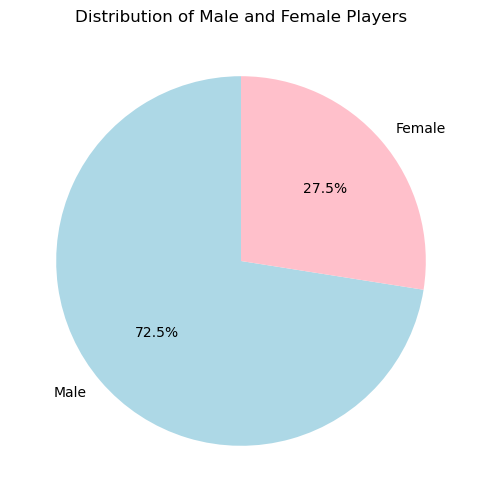

In [33]:
# Count values in the "Sex" column
sex_counts = olympic_worlds["Sex"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sex_counts,
    labels=sex_counts.index,   # Male/Female labels
    autopct='%1.1f%%',         # show percentages
    startangle=90,             # rotate start
    colors=['lightblue', 'pink']  # optional colors
)
plt.title("Distribution of Male and Female Players")
plt.show()

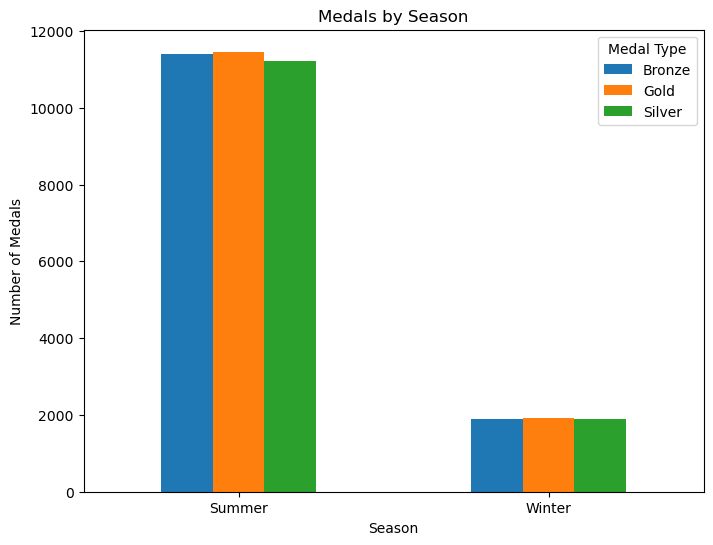

In [39]:
# Drop NaN medals
df_medals = olympic_worlds.dropna(subset=["Medal"])

# Create pivot table: Seasons as rows, Medals as columns
medal_pivot = df_medals.pivot_table(
    index="Season", 
    columns="Medal", 
    values="Sex",  # just counts rows
    aggfunc="count",
    fill_value=0   # replace NaN with 0
)

# Plot bar chart
medal_pivot.plot(kind="bar", figsize=(8,6))

plt.title("Medals by Season")
plt.ylabel("Number of Medals")
plt.xlabel("Season")
plt.xticks(rotation=0)  # keep labels horizontal
plt.legend(title="Medal Type")
plt.show()

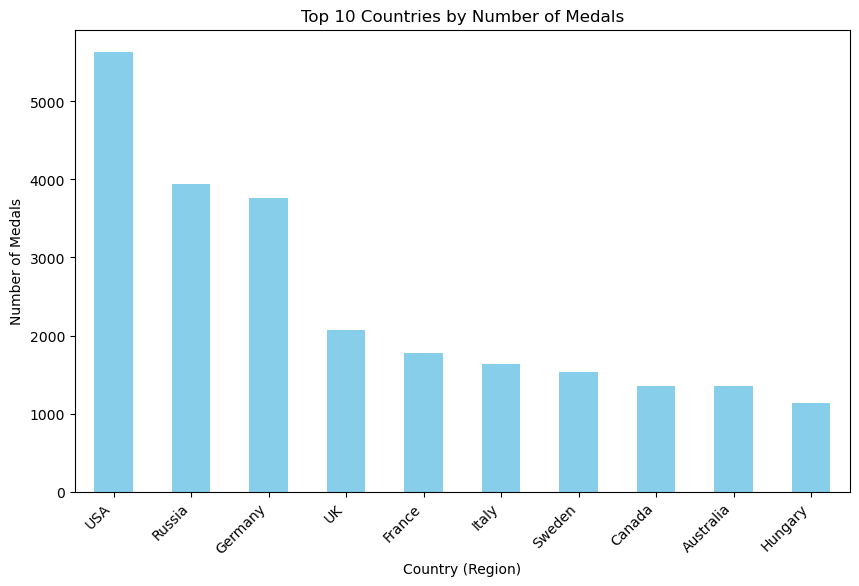

In [41]:
# Drop rows without medals
df_medals = olympic_worlds.dropna(subset=["Medal"])

# Count medals by region
top_countries = (
    df_medals["region"]
    .value_counts()
    .head(10)   # top 10
)

# Plot bar chart
plt.figure(figsize=(10,6))
top_countries.plot(kind="bar", color="skyblue")

plt.title("Top 10 Countries by Number of Medals")
plt.xlabel("Country (Region)")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45, ha="right")
plt.show()

In [49]:
# Keep only medals (drop NaN in Medal)
df_medals = olympic_worlds.dropna(subset=["Medal"])

# Count all medals for China
china_total = (df_medals["region"] == "China").sum()

print("Total medals for China:", china_total)

Total medals for China: 993


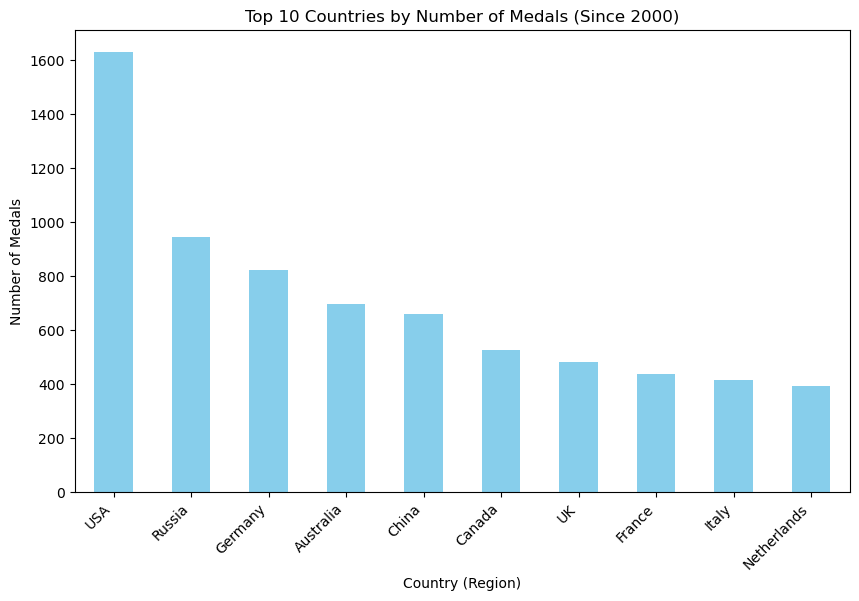

In [50]:
# to find alive coaches, we will search for best 10 countrieas from 2000

# Drop rows without medals
df_medals = olympic_worlds.dropna(subset=["Medal"])

# Filter for Year >= 2000
df_medals_recent = df_medals[df_medals["Year"] >= 2000]

# Count medals by region
top_countries_recent = (
    df_medals_recent["region"]
    .value_counts()
    .head(10)   # top 10
)

# Plot bar chart
plt.figure(figsize=(10,6))
top_countries_recent.plot(kind="bar", color="skyblue")

plt.title("Top 10 Countries by Number of Medals (Since 2000)")
plt.xlabel("Country (Region)")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45, ha="right")
plt.show()

olympic_game_types:


Sport
Athletics        22018
Swimming          8720
Rowing            7687
Football          6129
Cycling           5815
                 ...  
Croquet             10
Racquets             7
Roque                4
Basque Pelota        2
Aeronautics          1
Name: ID, Length: 66, dtype: int64

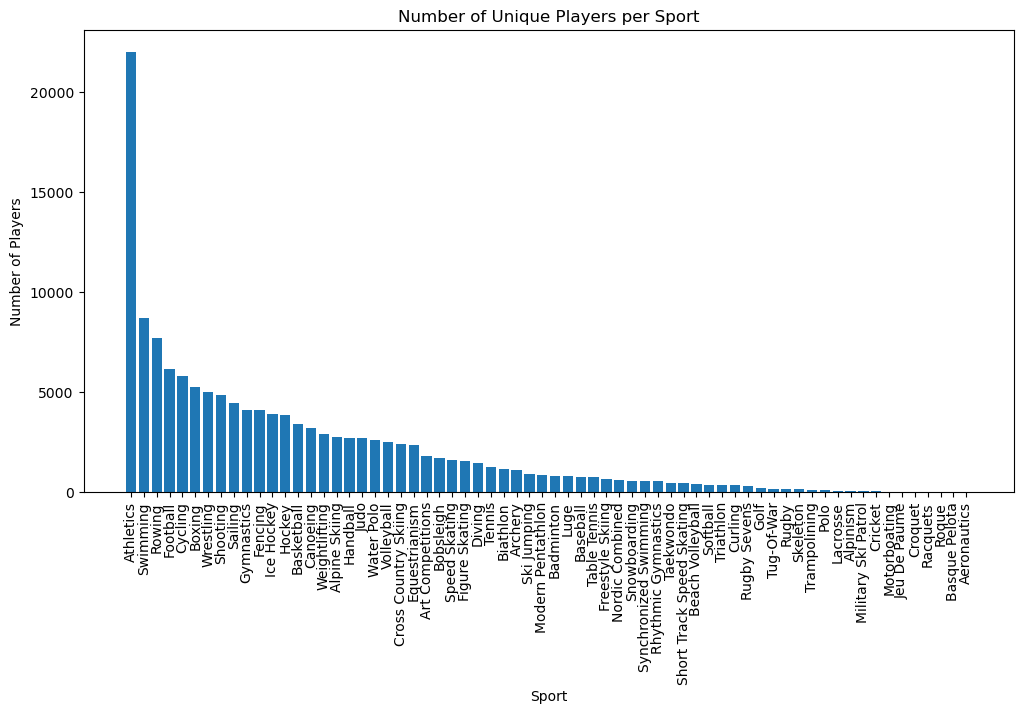

In [54]:
#Here I want to explore what are the most common games using df.groupby('group_column')['value_column'].nunique() then we are sorting it
olympic_game_types = olympic_worlds.groupby('Sport')['ID'].nunique().sort_values(ascending=False)

print("olympic_game_types:")
display(olympic_game_types)

#Here i want to make my chart using a bar chart
plt.figure(figsize=(12, 6)) #We will make it bigger so we can read it properly
plt.bar(olympic_game_types.index, olympic_game_types.values)

# here we will format the data for us to better understand it
plt.xlabel('Sport')
plt.ylabel('Number of Players')
plt.title('Number of Unique Players per Sport')
plt.xticks(rotation=90)

#Let us vew our work
plt.show()

Sport
Athletics     22018
Swimming       8720
Rowing         7687
Football       6129
Cycling        5815
Boxing         5257
Wrestling      4974
Shooting       4857
Sailing        4446
Gymnastics     4120
Name: ID, dtype: int64

Text(0.5, 1.0, 'Concentration of players in the Olympics (top 10 games)')

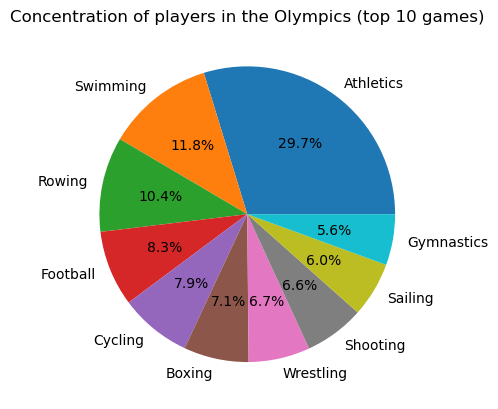

In [55]:
#let us find the top 10 games and put them in a pie chart

top_games = olympic_game_types.head(10)
display(top_games)

plt.pie(top_games.values, labels = top_games.index, autopct='%1.1f%%')
plt.title('Concentration of players in the Olympics (top 10 games)')

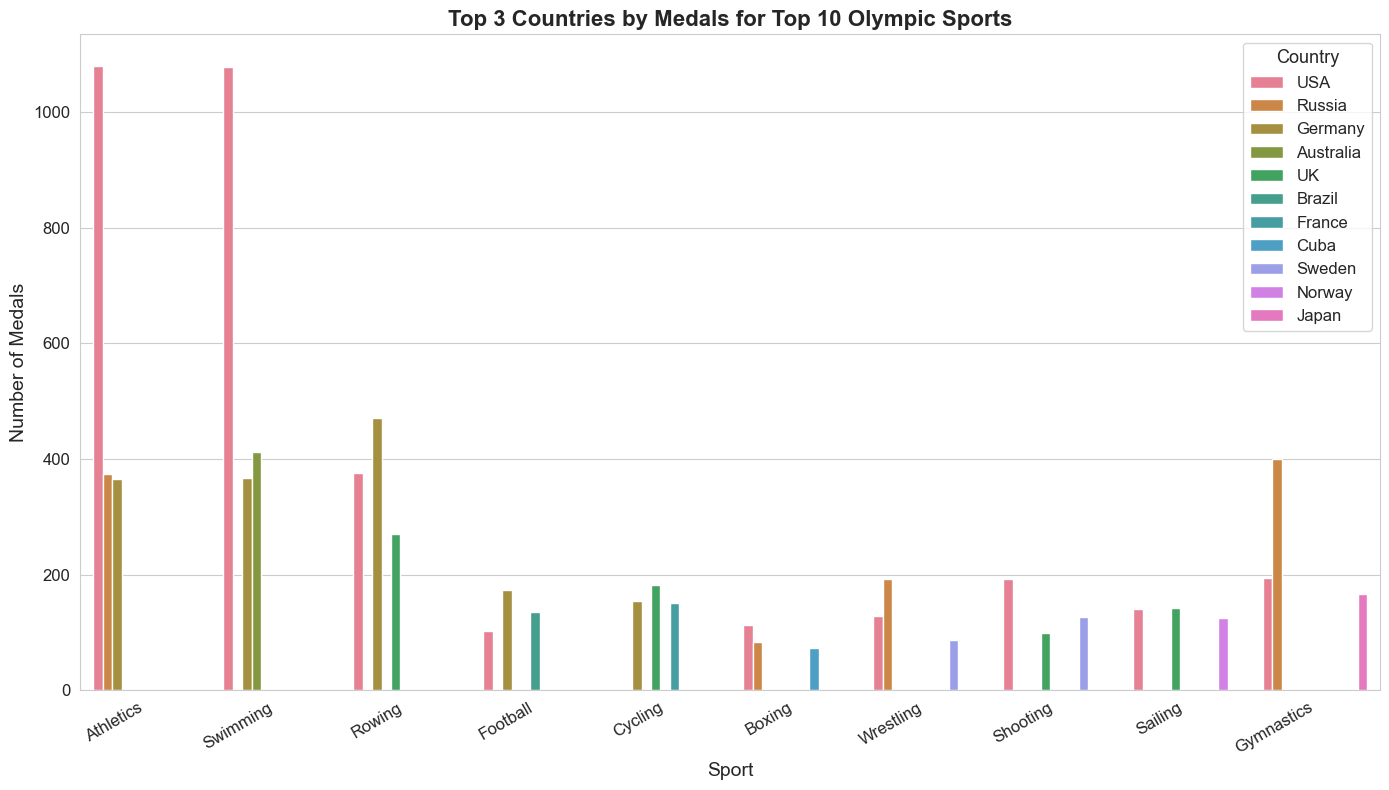

In [65]:
# Step 1: Drop rows without medals
df_medals = olympic_worlds.dropna(subset=["Medal"])

# Step 2: Get top 10 sports (from your previous top_games)
top_games_list = top_games.index

# Step 3: Prepare a DataFrame for top 3 countries per sport
top_countries_per_sport = pd.DataFrame()

for sport in top_games_list:
    df_sport = df_medals[df_medals["Sport"] == sport]
    country_counts = df_sport["region"].value_counts().head(3)
    
    temp_df = pd.DataFrame({
        "Sport": sport,
        "Country": country_counts.index,
        "Medals": country_counts.values
    })
    
    top_countries_per_sport = pd.concat([top_countries_per_sport, temp_df], ignore_index=True)

# Step 4: Plot a clean grouped bar chart using Seaborn
plt.figure(figsize=(14,8))
sns.set_style("whitegrid")  # clean background
sns.set_palette("pastel")   # easy on the eyes colors

sns.barplot(
    dta=top_countries_per_sport,
    x="Sport",
    y="Medals",
    hue="Country"
)

# Step 5: Improve readability
plt.title("Top 3 Countries by Medals for Top 10 Olympic Sports", fontsize=16, weight='bold')
plt.xlabel("Sport", fontsize=14)
plt.ylabel("Number of Medals", fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Country", fontsize=12, title_fontsize=13, loc="upper right")

plt.tight_layout()  # avoids clipping labels
plt.show()


---

## Summary
__Summarizing the key insights from the analysis__

**Note**: _Use Bullet Points_
 - The highest number of participants in the history of the recorded Olympics was 72.5% for men, while women achieved 27.5%.
 - The highest number of medals registered in the summer season compared to the winter season.
 - The sports with the most participants are Athletics, Swimming, Rowing, Football, Cycling, Boxing, Wrestling, Shooting, Sailing, and Gymnastics.
 - Throughout the history of the Olympics, the largest medal counts belong to the USA, followed by Russia and Germany.
 - Best countries to get expertise from per sport are:
    * Athletics: USA, Russia, Germany
    * Swimming: USA, Australia, Germany
    * Rowing: Germany, USA, UK
    * Football: Germany, Brazil, USA
    * Cycling: UK, Germany, France
    * Boxing: USA, Russia, Cuba
    * Wrestling: Russia, USA, Sweden
    * Shooting: USA, Sweden, UK
    * Sailing: UK, USA, Norway
    * Gymnastics: Russia, USA, Japan    ...

## Recommendations/Conclusion
**Note**: _Use Bullet Points_
- Based on the studies we conducted the following games show a huge participation, where Bahrain should focus its investments:
  Athletics, Swimming, Rowing, Football, Cycling, Boxing, Wrestling, Shooting, Sailing, Gymnastics.
- The Bahrain Olympic Committee is advised to recruit coaches from nations with the highest medal counts in particular Olympic events.
  * 
    ...